In [1]:
# coding: utf-8

In [2]:
# Curation vs Retrieval Experiment Comparison
# ==========================================
# This notebook compares the performance of three models (gpt-4.1, o4-mini, Qwen3-32B)
# across two datasets (nlp4lp, nlp4opt) using both curation and retrieval methods.

# Import core libraries with compatibility checks
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import json
import re
from collections import defaultdict
import warnings

# Check for potential compatibility issues
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Pandas version: {pd.__version__}")

# Suppress common warnings that might cause issues
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Safe array conversion without patching numpy
def safe_array_convert(data):
    """
    Safely convert data to numpy array, handling type conversion issues.
    """
    try:
        if hasattr(data, 'values'):
            # Pandas Series/DataFrame
            return np.array(data.values, dtype=np.float64)
        elif isinstance(data, (list, tuple)):
            return np.array(data, dtype=np.float64)
        elif isinstance(data, np.ndarray):
            return np.array(data, dtype=np.float64)
        else:
            return np.array(data, dtype=np.float64)
    except Exception as e:
        print(f"Array conversion warning: {e}")
        try:
            return np.array(data, dtype=object)
        except:
            return np.array([])

# Additional safeguards for matplotlib array handling
def safe_matplotlib_conversion(func):
    """
    Decorator to handle matplotlib numpy array conversion errors.
    """
    def wrapper(*args, **kwargs):
        try:
            # Convert any numpy arrays to safe format
            safe_args = []
            for arg in args:
                if hasattr(arg, '__array__') or isinstance(arg, np.ndarray):
                    safe_args.append(safe_array_convert(arg))
                else:
                    safe_args.append(arg)
            
            safe_kwargs = {}
            for key, value in kwargs.items():
                if hasattr(value, '__array__') or isinstance(value, np.ndarray):
                    safe_kwargs[key] = safe_array_convert(value)
                else:
                    safe_kwargs[key] = value
                    
            return func(*safe_args, **safe_kwargs)
        except Exception as e:
            if "Cannot convert numpy.ndarray" in str(e):
                print(f"Handled numpy array conversion in {func.__name__}")
                # Try with basic Python types
                basic_args = []
                for arg in args:
                    if hasattr(arg, '__iter__') and not isinstance(arg, str):
                        basic_args.append(list(arg))
                    else:
                        basic_args.append(arg)
                return func(*basic_args, **{k: v for k, v in kwargs.items() if not hasattr(v, '__array__')})
            else:
                raise e
    return wrapper

print("Advanced numpy array conversion protection loaded")

# Set matplotlib backend for Jupyter notebook display
try:
    # Use inline backend for Jupyter notebooks
    matplotlib.use('module://matplotlib_inline.backend_inline')
    print("Using inline backend for matplotlib")
except:
    try:
        # Fallback to interactive backend that works in Jupyter
        matplotlib.use('notebook')
        print("Using notebook backend for matplotlib")
    except:
        try:
            # Another fallback
            matplotlib.use('widget')
            print("Using widget backend for matplotlib")
        except:
            print("Using default matplotlib backend")

# Try to import seaborn with comprehensive error handling
try:
    # Check scipy compatibility first
    try:
        import scipy
        print(f"SciPy version: {scipy.__version__}")
    except ImportError:
        print("SciPy not available - some seaborn features may be limited")
    
    import seaborn as sns
    SEABORN_AVAILABLE = True
    print("Seaborn imported successfully")
    
    # Test seaborn basic functionality
    try:
        sns.set_theme()  # Test if seaborn works without errors
        print("Seaborn theme set successfully")
    except Exception as e:
        print(f"Seaborn theme error: {e}")
        SEABORN_AVAILABLE = False
        
except (ImportError, ValueError, Exception) as e:
    SEABORN_AVAILABLE = False
    print(f"Seaborn not available ({type(e).__name__}: {e}) - using matplotlib only")

# Create fallback seaborn object if needed
if not SEABORN_AVAILABLE:
    class DummySeaborn:
        def __init__(self):
            self.__version__ = "fallback"
            
        def set_palette(self, *args, **kwargs):
            pass
            
        def set_theme(self, *args, **kwargs):
            pass
            
        def heatmap(self, data, *args, **kwargs):
            # Extract the axis if provided
            ax = kwargs.get('ax', plt.gca())
            try:
                # Use matplotlib's imshow as fallback with safe array conversion
                if hasattr(data, 'values'):
                    data_array = safe_array_convert(data.values)
                else:
                    data_array = safe_array_convert(data)
                
                im = ax.imshow(data_array, cmap=kwargs.get('cmap', 'viridis'), aspect='auto')
                return im
            except Exception as e:
                print(f"Fallback heatmap error: {e}")
                return None
                
    sns = DummySeaborn()

# Import functions from accuracy_analyzer
from accuracy_analyzer import analyze_accuracy

# Set up plotting
get_ipython().run_line_magic('matplotlib', 'inline')

# Configure matplotlib style
if SEABORN_AVAILABLE:
    try:
        plt.style.use('seaborn-v0_8')
        print("Using seaborn-v0_8 style")
    except OSError:
        try:
            plt.style.use('seaborn')
            print("Using seaborn style")
        except OSError:
            plt.style.use('default')
            print("Using default style - seaborn styles not available")
else:
    plt.style.use('default')
    print("Using matplotlib default style")

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Set color palette
if SEABORN_AVAILABLE:
    try:
        sns.set_palette("husl")
        print("Seaborn palette set")
    except:
        print("Could not set seaborn palette - using matplotlib defaults")
else:
    # Set matplotlib color cycle as fallback
    plt.rcParams['axes.prop_cycle'] = plt.cycler('color', 
        ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])

print("Libraries imported successfully!")
print("Ready to analyze curation vs retrieval experiments...")

NumPy version: 1.26.4
Matplotlib version: 3.10.3
Pandas version: 2.2.3
Advanced numpy array conversion protection loaded
Using inline backend for matplotlib
SciPy version: 1.15.3
Seaborn not available (ValueError: All ufuncs must have type `numpy.ufunc`. Received (<ufunc 'sph_legendre_p'>, <ufunc 'sph_legendre_p'>, <ufunc 'sph_legendre_p'>)) - using matplotlib only
Using matplotlib default style
Libraries imported successfully!
Ready to analyze curation vs retrieval experiments...


In [3]:
# Additional Safe Plotting Functions
# ===================================

def safe_bar_plot(ax, x, y, **kwargs):
    """
    Safe bar plotting with array conversion to prevent numpy.ndarray errors.
    """
    try:
        # Convert to safe arrays
        x_safe = list(x) if not isinstance(x, (list, tuple, range)) else list(x)
        y_safe = safe_array_convert(y)
        
        # Handle yerr parameter specially
        if 'yerr' in kwargs:
            yerr_safe = safe_array_convert(kwargs['yerr'])
            kwargs['yerr'] = yerr_safe
            
        return ax.bar(x_safe, y_safe, **kwargs)
    except Exception as e:
        print(f"Bar plot error: {e}")
        # Ultra-safe fallback
        try:
            safe_kwargs = {k: v for k, v in kwargs.items() if k != 'yerr'}
            y_list = [float(val) for val in y]
            return ax.bar(range(len(y_list)), y_list, **safe_kwargs)
        except:
            return None

def safe_imshow(ax, data, **kwargs):
    """
    Safe imshow with array conversion to prevent numpy.ndarray errors.
    """
    try:
        # Convert data to safe numpy array
        if hasattr(data, 'values'):
            data_safe = safe_array_convert(data.values)
        else:
            data_safe = safe_array_convert(data)
        
        return ax.imshow(data_safe, **kwargs)
    except Exception as e:
        print(f"Imshow error: {e}")
        return None

def safe_hist(ax, data, **kwargs):
    """
    Safe histogram plotting with array conversion.
    """
    try:
        data_safe = safe_array_convert(data)
        # Remove any NaN or inf values
        data_clean = data_safe[np.isfinite(data_safe)]
        
        return ax.hist(data_clean, **kwargs)
    except Exception as e:
        print(f"Histogram error: {e}")
        return None

def safe_plot(ax, x, y, **kwargs):
    """
    Safe line plotting with array conversion.
    """
    try:
        x_safe = safe_array_convert(x)
        y_safe = safe_array_convert(y)
        return ax.plot(x_safe, y_safe, **kwargs)
    except Exception as e:
        print(f"Plot error: {e}")
        return None

def safe_boxplot(ax, data, **kwargs):
    """
    Safe boxplot with array conversion.
    """
    try:
        if isinstance(data, list):
            data_safe = [safe_array_convert(d) for d in data]
        else:
            data_safe = safe_array_convert(data)
        return ax.boxplot(data_safe, **kwargs)
    except Exception as e:
        print(f"Boxplot error: {e}")
        return None

# No more aggressive patching - use manual safe functions when needed
print("Safe plotting functions available for manual use")

print("Safe plotting functions loaded successfully")

Safe plotting functions available for manual use
Safe plotting functions loaded successfully


In [4]:
def discover_experiment_files():
    """
    Auto-discover all experiment result files in the datasets directory.
    Returns a structured dictionary of experiment files.
    """
    datasets_dir = Path("datasets")
    
    # Check if datasets directory exists
    if not datasets_dir.exists():
        print(f"Datasets directory not found: {datasets_dir}")
        return {}
    
    experiment_files = defaultdict(lambda: defaultdict(dict))
    
    # Models to look for (with variations)
    model_patterns = {
        "gpt-4.1": ["gpt-4.1", "gpt4.1", "gpt-4"],
        "o4-mini": ["o4-mini", "o1-mini", "gpt-4o-mini"],
        "Qwen-Qwen3-32B": ["Qwen-Qwen3-32B", "Qwen3-32B", "qwen"]
    }
    
    datasets = ["nlp4lp", "nlp4opt"]
    
    print("Discovering experiment files...")
    print("=" * 50)
    
    # First, scan all subdirectories in datasets/
    for subdir in datasets_dir.iterdir():
        if not subdir.is_dir():
            continue
            
        dir_name = subdir.name.lower()
        print(f"Examining directory: {subdir}")
        
        # Try to identify dataset and model from directory name
        identified_dataset = None
        identified_model = None
        
        for dataset in datasets:
            if dataset in dir_name:
                identified_dataset = dataset
                break
        
        for model_key, model_variants in model_patterns.items():
            for variant in model_variants:
                if variant.lower().replace("-", "").replace(".", "") in dir_name.replace("-", "").replace(".", ""):
                    identified_model = model_key
                    break
            if identified_model:
                break
        
        if not identified_dataset or not identified_model:
            print(f"  Could not identify dataset/model from directory name: {dir_name}")
            continue
        
        # Look for JSONL files in this directory
        jsonl_files = list(subdir.glob("*.jsonl"))
        if not jsonl_files:
            print(f"  No JSONL files found in: {subdir}")
            continue
        
        print(f"  Identified: {identified_dataset} + {identified_model}")
        
        # Process each JSONL file
        for jsonl_file in jsonl_files:
            file_name = jsonl_file.name.lower()
            
            # Determine if it's curation or retrieval
            method = "unknown"
            if "curation" in file_name or "curate" in file_name:
                method = "curation"
            elif "retrieval" in file_name or "retrieve" in file_name or "ret" in file_name:
                method = "retrieval"
            elif "kb" in file_name or "knowledge" in file_name:
                method = "curation"
            else:
                # Try to infer from file content
                method = infer_method_from_content(jsonl_file)
            
            if method != "unknown":
                experiment_files[identified_model][identified_dataset][method] = str(jsonl_file)
                print(f"    {method}: {jsonl_file.name}")
            else:
                print(f"    Could not determine method for: {jsonl_file.name}")
    
    return dict(experiment_files)

def infer_method_from_content(file_path, sample_size=5):
    """
    Infer experiment method by examining response formats in the file.
    Curation experiments typically have longer, more detailed responses.
    """
    try:
        with open(file_path, 'r') as f:
            total_response_length = 0
            count = 0
            
            for i, line in enumerate(f):
                if i >= sample_size:
                    break
                try:
                    data = json.loads(line)
                    response = str(data.get('agent_response', ''))
                    total_response_length += len(response)
                    count += 1
                except:
                    continue
            
            if count > 0:
                avg_length = total_response_length / count
                # If average response length > 100 chars, likely curation
                return "curation" if avg_length > 100 else "retrieval"
    except:
        pass
    
    return "unknown"

# Discover all experiment files
experiment_files = discover_experiment_files()

print(f"\nSummary:")
print(f"Found experiments for {len(experiment_files)} models")
for model, datasets in experiment_files.items():
    for dataset, methods in datasets.items():
        print(f"  {model} - {dataset}: {list(methods.keys())}")

if not experiment_files:
    print("No experiment files found. Please check your file structure.")
else:
    print(f"\nReady to analyze {sum(len(methods) for datasets in experiment_files.values() for methods in datasets.values())} experiment files")

Discovering experiment files...
Examining directory: datasets/nlp4opt_o4-mini
  Identified: nlp4opt + o4-mini
    retrieval: nlp4opt_o4-mini_retrieval.jsonl
    curation: nlp4opt_o4-mini_curation.jsonl
Examining directory: datasets/nlp4opt_gpt-4.1
  Identified: nlp4opt + gpt-4.1
    retrieval: nlp4opt_gpt-4.1_retrieval.jsonl
    curation: nlp4opt_gpt-4.1_curation.jsonl
Examining directory: datasets/industryor_gpt-4.1
  Could not identify dataset/model from directory name: industryor_gpt-4.1
Examining directory: datasets/industryor
  Could not identify dataset/model from directory name: industryor
Examining directory: datasets/nlp4lp_gpt-4.1
  Identified: nlp4lp + gpt-4.1
    curation: nlp4lp_gpt-4.1_curation.jsonl
    retrieval: nlp4lp_gpt-4.1_retrieval.jsonl
Examining directory: datasets/industryor_o4-mini
  Could not identify dataset/model from directory name: industryor_o4-mini
Examining directory: datasets/nlp4lp_o4-mini
  Identified: nlp4lp + o4-mini
    curation: nlp4lp_o4-mini_c

In [5]:
# Analyze all experiments
print("Starting simple analysis...")
if experiment_files:
    print("ACCURACY RESULTS")
    print("=" * 60)
    
    curation_results = []
    retrieval_results = []
    all_results = []
    
    for model in experiment_files:
        for dataset in experiment_files[model]:
            for method in experiment_files[model][dataset]:
                file_path = experiment_files[model][dataset][method]
                result = analyze_accuracy(file_path, threshold=1e-4)
                
                accuracy = float(str(result['accuracy_percentage']))
                
                print(f"{model:>15} | {dataset:>8} | {method:>10} | {accuracy:6.2f}%")
                
                all_results.append({
                        'model': model,
                        'dataset': dataset,
                    'method': method,
                    'accuracy': accuracy
                })
                
                if method == 'curation':
                    curation_results.append(accuracy)
                elif method == 'retrieval':
                    retrieval_results.append(accuracy)
    
    # Simple summary
    print(f"\nSUMMARY")
    print("=" * 30)
    
    if curation_results:
        curation_avg = sum(curation_results) / len(curation_results)
        print(f"Curation:  {curation_avg:6.2f}% (n={len(curation_results)})")
    
    if retrieval_results:
        retrieval_avg = sum(retrieval_results) / len(retrieval_results)
        print(f"Retrieval: {retrieval_avg:6.2f}% (n={len(retrieval_results)})")
    
    if curation_results and retrieval_results:
        improvement = curation_avg - retrieval_avg
        print(f"Difference: {improvement:5.2f}% (Curation - Retrieval)")
        
        if improvement > 0:
            print("Curation performs better!")
        elif improvement < 0:
            print("Retrieval performs better!")
        else:
            print("No significant difference")
    
    print(f"\nAnalysis complete! Processed {len(all_results)} experiments.")
    
else:
    print("No experiment files found")

Starting simple analysis...
ACCURACY RESULTS
        o4-mini |  nlp4opt |  retrieval |  74.78%
        o4-mini |  nlp4opt |   curation |  74.67%
        o4-mini |   nlp4lp |   curation |  70.12%
        o4-mini |   nlp4lp |  retrieval |  68.05%
        gpt-4.1 |  nlp4opt |  retrieval |  71.93%
        gpt-4.1 |  nlp4opt |   curation |  75.98%
        gpt-4.1 |   nlp4lp |   curation |  71.37%
        gpt-4.1 |   nlp4lp |  retrieval |  65.56%
 Qwen-Qwen3-32B |  nlp4opt |   curation |  73.80%
 Qwen-Qwen3-32B |  nlp4opt |  retrieval |  71.62%
 Qwen-Qwen3-32B |   nlp4lp |  retrieval |  72.20%
 Qwen-Qwen3-32B |   nlp4lp |   curation |  67.77%

SUMMARY
Curation:   72.29% (n=6)
Retrieval:  70.69% (n=6)
Difference:  1.60% (Curation - Retrieval)
Curation performs better!

Analysis complete! Processed 12 experiments.


Starting threshold sensitivity analysis...
Testing thresholds: [0.0001, 0.001, 0.01, 0.1, 0.2, 0.5, 1.0]
Analyzing threshold sensitivity...
  Testing threshold: 0.0001
  Testing threshold: 0.001
  Testing threshold: 0.01
  Testing threshold: 0.1
  Testing threshold: 0.2
  Testing threshold: 0.5
  Testing threshold: 1.0
Creating threshold sensitivity plots...


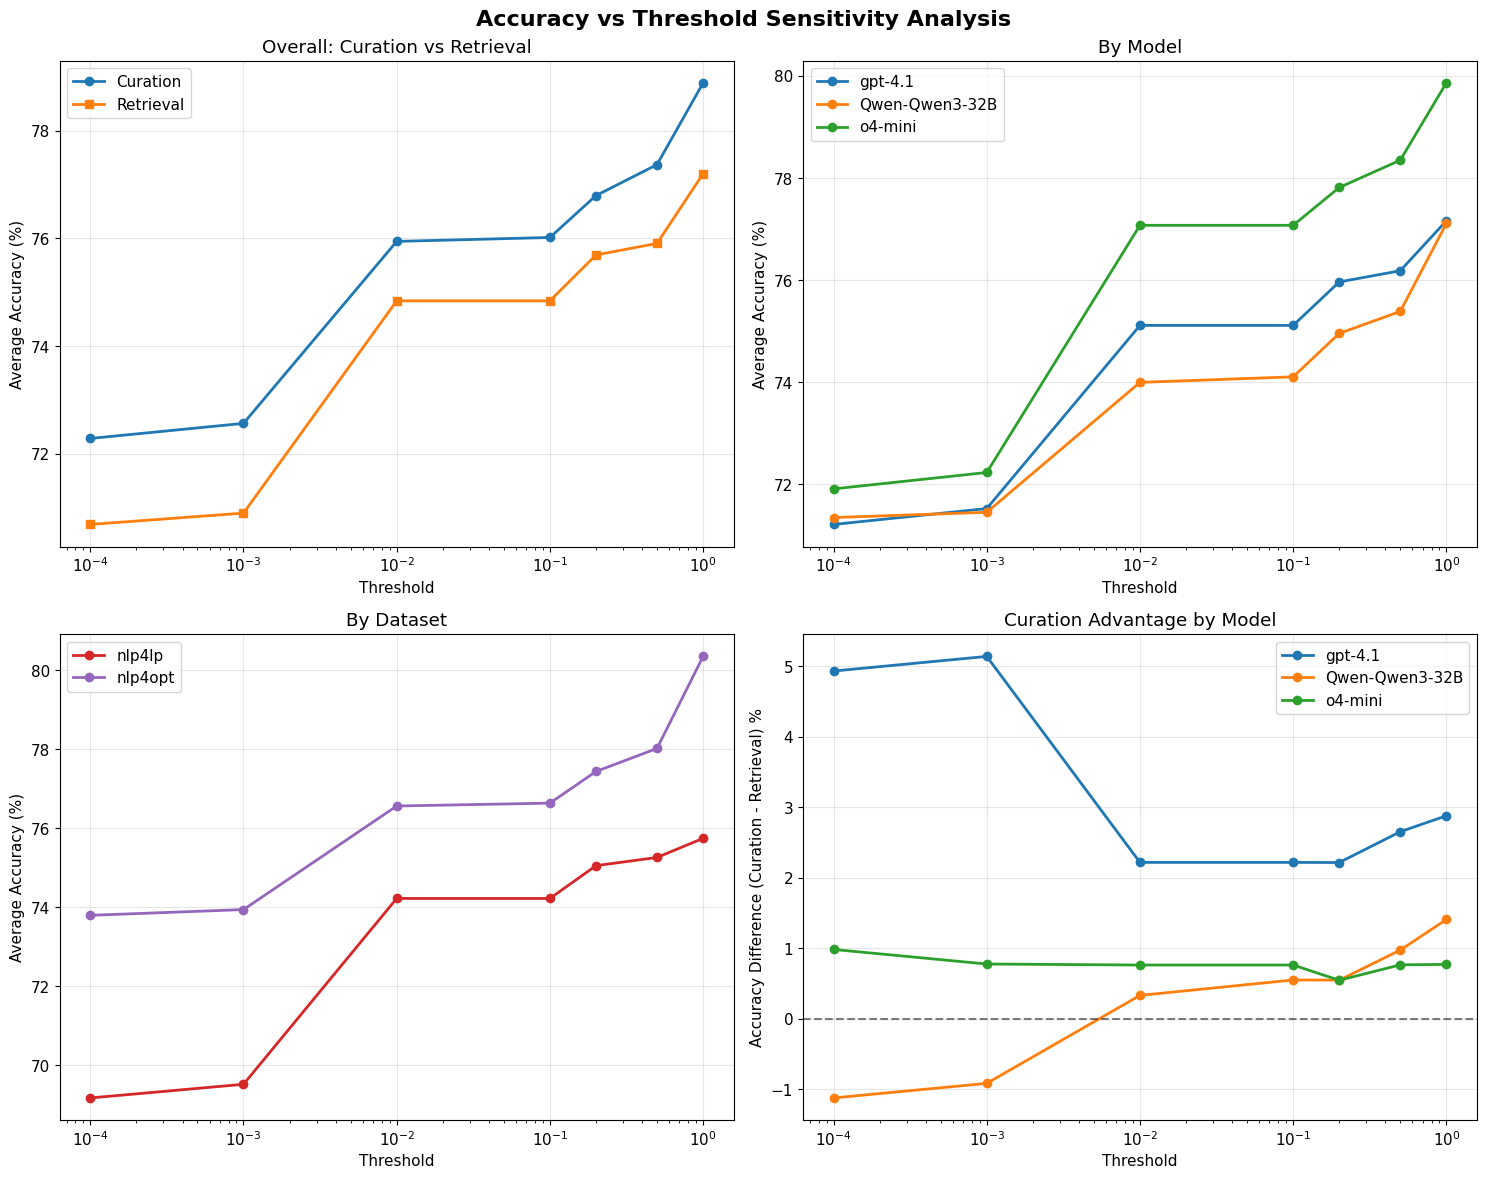


THRESHOLD SENSITIVITY SUMMARY
Threshold 1.0e-04: Curation  72.3% | Retrieval  70.7% | Diff  +1.6%
Threshold 1.0e-03: Curation  72.6% | Retrieval  70.9% | Diff  +1.7%
Threshold 1.0e-02: Curation  75.9% | Retrieval  74.8% | Diff  +1.1%
Threshold 1.0e-01: Curation  76.0% | Retrieval  74.8% | Diff  +1.2%
Threshold 2.0e-01: Curation  76.8% | Retrieval  75.7% | Diff  +1.1%
Threshold 5.0e-01: Curation  77.4% | Retrieval  75.9% | Diff  +1.5%
Threshold 1.0e+00: Curation  78.9% | Retrieval  77.2% | Diff  +1.7%

Threshold sensitivity analysis complete!


In [6]:
# Threshold Sensitivity Analysis and Visualization
# ===============================================

def analyze_threshold_sensitivity(experiment_files, threshold_range):
    """
    Analyze how accuracy changes across different threshold values.
    """
    print("Analyzing threshold sensitivity...")
    
    # Store results for each threshold
    threshold_results = []
    
    for threshold in threshold_range:
        print(f"  Testing threshold: {threshold}")
        
        threshold_data = {
            'threshold': threshold,
            'results': []
        }
        
        for model in experiment_files:
            for dataset in experiment_files[model]:
                for method in experiment_files[model][dataset]:
                    file_path = experiment_files[model][dataset][method]
                    result = analyze_accuracy(file_path, threshold=threshold)
                    
                    accuracy = float(str(result['accuracy_percentage']))
                    
                    threshold_data['results'].append({
                        'model': model,
                        'dataset': dataset,
                        'method': method,
                        'accuracy': accuracy,
                        'threshold': threshold
                    })
        
        threshold_results.append(threshold_data)
    
    return threshold_results

def plot_threshold_sensitivity(threshold_results):
    """
    Create visualizations showing how accuracy changes with threshold.
    """
    print("Creating threshold sensitivity plots...")
    
    # Prepare data for plotting
    thresholds = [tr['threshold'] for tr in threshold_results]
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Accuracy vs Threshold Sensitivity Analysis', fontsize=16, fontweight='bold')
    
    # Plot 1: Overall Curation vs Retrieval
    ax1 = axes[0, 0]
    curation_accuracies = []
    retrieval_accuracies = []
    
    for tr in threshold_results:
        curation_acc = [r['accuracy'] for r in tr['results'] if r['method'] == 'curation']
        retrieval_acc = [r['accuracy'] for r in tr['results'] if r['method'] == 'retrieval']
        
        curation_avg = sum(curation_acc) / len(curation_acc) if curation_acc else 0
        retrieval_avg = sum(retrieval_acc) / len(retrieval_acc) if retrieval_acc else 0
        
        curation_accuracies.append(curation_avg)
        retrieval_accuracies.append(retrieval_avg)
    
    ax1.plot(thresholds, curation_accuracies, 'o-', label='Curation', linewidth=2, markersize=6)
    ax1.plot(thresholds, retrieval_accuracies, 's-', label='Retrieval', linewidth=2, markersize=6)
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('Average Accuracy (%)')
    ax1.set_title('Overall: Curation vs Retrieval')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xscale('log')
    
    # Plot 2: By Model
    ax2 = axes[0, 1]
    models = list(set([r['model'] for tr in threshold_results for r in tr['results']]))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    for i, model in enumerate(models):
        model_accuracies = []
        for tr in threshold_results:
            model_acc = [r['accuracy'] for r in tr['results'] if r['model'] == model]
            model_avg = sum(model_acc) / len(model_acc) if model_acc else 0
            model_accuracies.append(model_avg)
        
        ax2.plot(thresholds, model_accuracies, 'o-', label=model, 
                linewidth=2, markersize=6, color=colors[i % len(colors)])
    
    ax2.set_xlabel('Threshold')
    ax2.set_ylabel('Average Accuracy (%)')
    ax2.set_title('By Model')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xscale('log')
    
    # Plot 3: By Dataset
    ax3 = axes[1, 0]
    datasets = list(set([r['dataset'] for tr in threshold_results for r in tr['results']]))
    
    for i, dataset in enumerate(datasets):
        dataset_accuracies = []
        for tr in threshold_results:
            dataset_acc = [r['accuracy'] for r in tr['results'] if r['dataset'] == dataset]
            dataset_avg = sum(dataset_acc) / len(dataset_acc) if dataset_acc else 0
            dataset_accuracies.append(dataset_avg)
        
        ax3.plot(thresholds, dataset_accuracies, 'o-', label=dataset, 
                linewidth=2, markersize=6, color=['#d62728', '#9467bd'][i % 2])
    
    ax3.set_xlabel('Threshold')
    ax3.set_ylabel('Average Accuracy (%)')
    ax3.set_title('By Dataset')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_xscale('log')
    
    # Plot 4: Method Comparison by Model
    ax4 = axes[1, 1]
    
    for i, model in enumerate(models):
        curation_model = []
        retrieval_model = []
        
        for tr in threshold_results:
            curation_acc = [r['accuracy'] for r in tr['results'] 
                          if r['model'] == model and r['method'] == 'curation']
            retrieval_acc = [r['accuracy'] for r in tr['results'] 
                           if r['model'] == model and r['method'] == 'retrieval']
            
            curation_avg = sum(curation_acc) / len(curation_acc) if curation_acc else 0
            retrieval_avg = sum(retrieval_acc) / len(retrieval_acc) if retrieval_acc else 0
            
            curation_model.append(curation_avg)
            retrieval_model.append(retrieval_avg)
        
        # Plot difference (Curation - Retrieval)
        difference = [c - r for c, r in zip(curation_model, retrieval_model)]
        ax4.plot(thresholds, difference, 'o-', label=model, 
                linewidth=2, markersize=6, color=colors[i % len(colors)])
    
    ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax4.set_xlabel('Threshold')
    ax4.set_ylabel('Accuracy Difference (Curation - Retrieval) %')
    ax4.set_title('Curation Advantage by Model')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.set_xscale('log')
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Define threshold range to test
threshold_range = [1e-4, 1e-3, 1e-2, 1e-1, 0.2, 0.5, 1.0]

print("Starting threshold sensitivity analysis...")
print(f"Testing thresholds: {threshold_range}")

# Run the analysis
if experiment_files:
    threshold_results = analyze_threshold_sensitivity(experiment_files, threshold_range)
    
    # Create visualizations
    fig = plot_threshold_sensitivity(threshold_results)
    
    # Print summary statistics
    print("\nTHRESHOLD SENSITIVITY SUMMARY")
    print("=" * 50)
    
    for tr in threshold_results:
        threshold = tr['threshold']
        curation_acc = [r['accuracy'] for r in tr['results'] if r['method'] == 'curation']
        retrieval_acc = [r['accuracy'] for r in tr['results'] if r['method'] == 'retrieval']
        
        if curation_acc and retrieval_acc:
            curation_avg = sum(curation_acc) / len(curation_acc)
            retrieval_avg = sum(retrieval_acc) / len(retrieval_acc)
            difference = curation_avg - retrieval_avg
            
            print(f"Threshold {threshold:6.1e}: Curation {curation_avg:5.1f}% | Retrieval {retrieval_avg:5.1f}% | Diff {difference:+5.1f}%")
    
    print(f"\nThreshold sensitivity analysis complete!")

else:
    print("No experiment files found")


Creating additional visualizations...


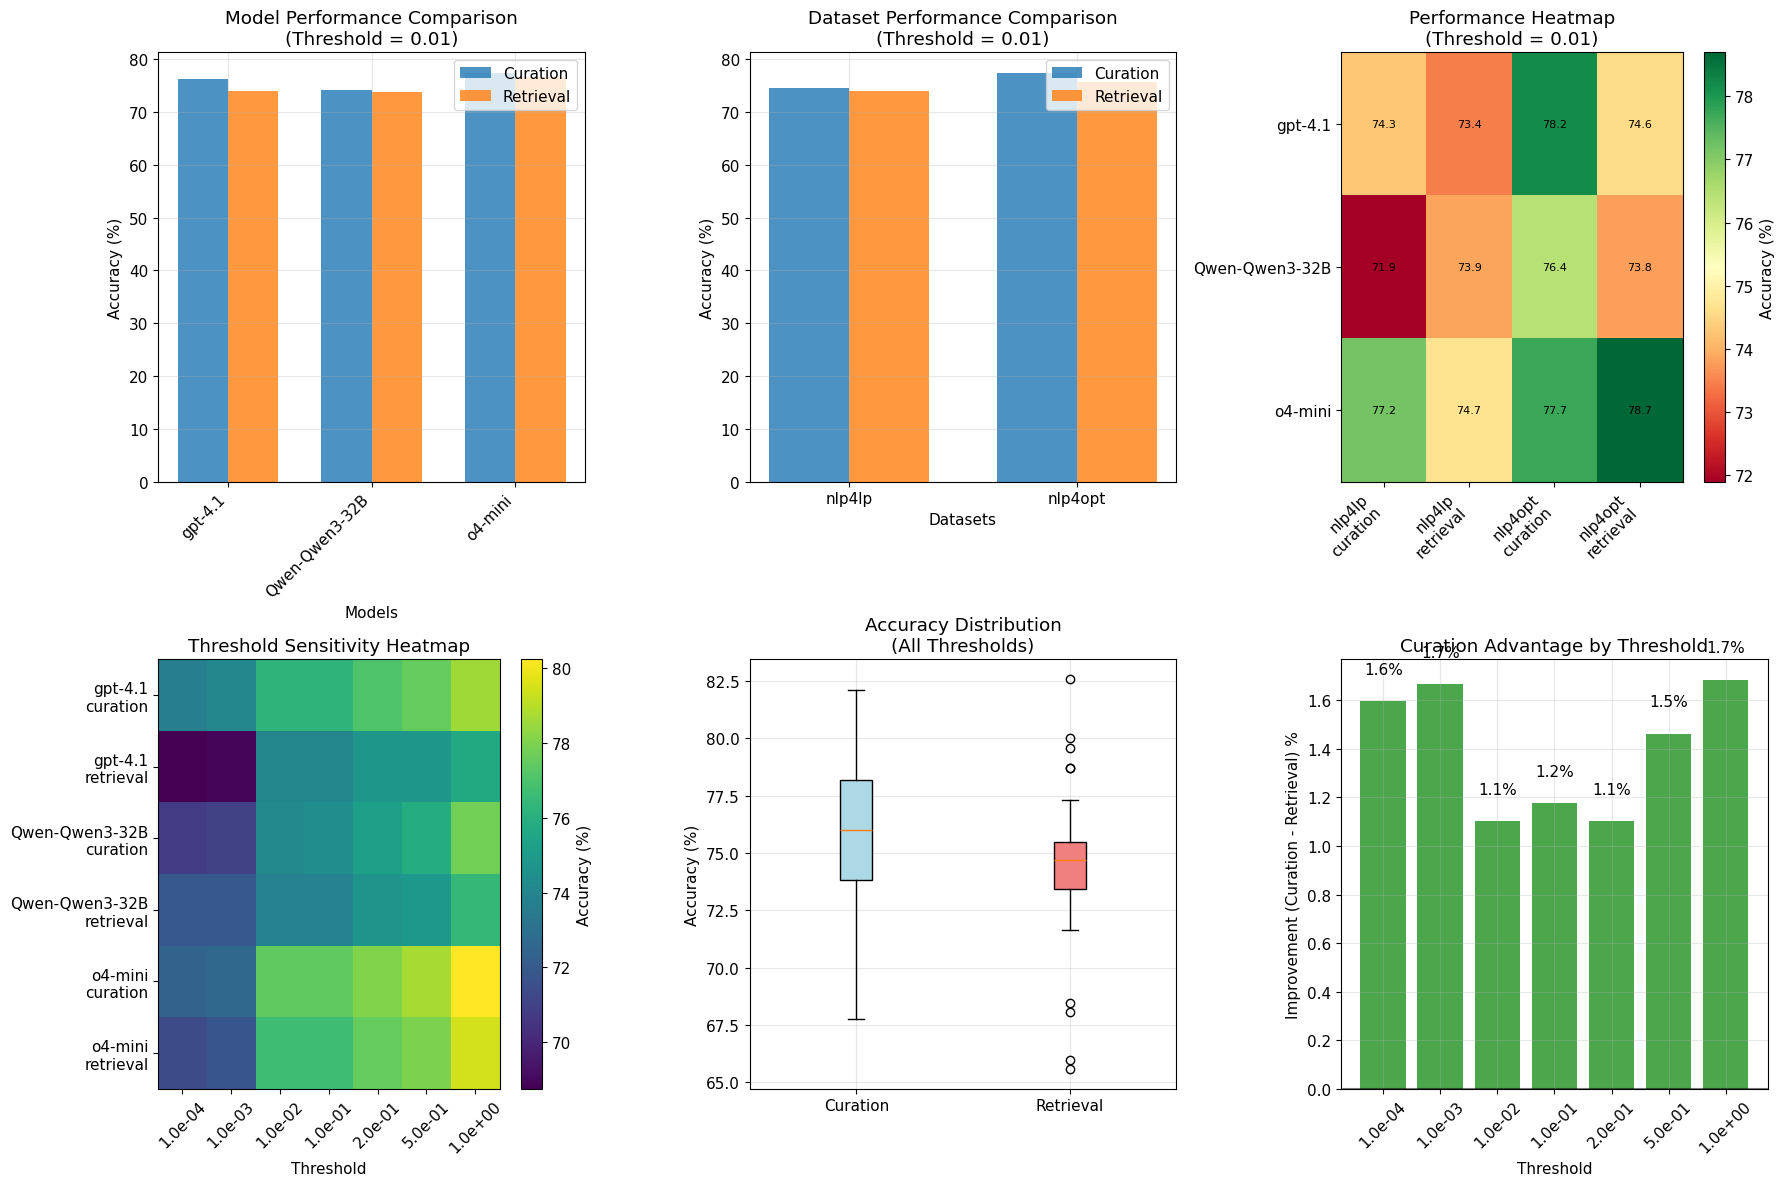

Additional visualizations created successfully!


In [7]:
# Additional Visualizations: Bar Charts and Heatmaps
# ==================================================

def create_additional_visualizations(threshold_results):
    """
    Create bar charts and heatmaps for better visualization.
    """
    print("Creating additional visualizations...")
    
    # Create figure with multiple subplots
    fig = plt.figure(figsize=(18, 12))
    
    # Extract data for visualizations
    thresholds = [tr['threshold'] for tr in threshold_results]
    models = list(set([r['model'] for tr in threshold_results for r in tr['results']]))
    datasets = list(set([r['dataset'] for tr in threshold_results for r in tr['results']]))
    
    # Plot 1: Bar chart showing current performance (threshold = 0.01)
    ax1 = plt.subplot(2, 3, 1)
    current_threshold_data = next((tr for tr in threshold_results if tr['threshold'] == 1e-2), threshold_results[2])
    
    model_performance = {}
    for model in models:
        curation_acc = [r['accuracy'] for r in current_threshold_data['results'] 
                       if r['model'] == model and r['method'] == 'curation']
        retrieval_acc = [r['accuracy'] for r in current_threshold_data['results'] 
                        if r['model'] == model and r['method'] == 'retrieval']
        
        model_performance[model] = {
            'curation': sum(curation_acc) / len(curation_acc) if curation_acc else 0,
            'retrieval': sum(retrieval_acc) / len(retrieval_acc) if retrieval_acc else 0
        }
    
    x_pos = range(len(models))
    curation_vals = [model_performance[m]['curation'] for m in models]
    retrieval_vals = [model_performance[m]['retrieval'] for m in models]
    
    width = 0.35
    ax1.bar([x - width/2 for x in x_pos], curation_vals, width, label='Curation', alpha=0.8)
    ax1.bar([x + width/2 for x in x_pos], retrieval_vals, width, label='Retrieval', alpha=0.8)
    
    ax1.set_xlabel('Models')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Model Performance Comparison\n(Threshold = 0.01)')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(models, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Dataset comparison bar chart
    ax2 = plt.subplot(2, 3, 2)
    dataset_performance = {}
    for dataset in datasets:
        curation_acc = [r['accuracy'] for r in current_threshold_data['results'] 
                       if r['dataset'] == dataset and r['method'] == 'curation']
        retrieval_acc = [r['accuracy'] for r in current_threshold_data['results'] 
                        if r['dataset'] == dataset and r['method'] == 'retrieval']
        
        dataset_performance[dataset] = {
            'curation': sum(curation_acc) / len(curation_acc) if curation_acc else 0,
            'retrieval': sum(retrieval_acc) / len(retrieval_acc) if retrieval_acc else 0
        }
    
    x_pos = range(len(datasets))
    curation_vals = [dataset_performance[d]['curation'] for d in datasets]
    retrieval_vals = [dataset_performance[d]['retrieval'] for d in datasets]
    
    ax2.bar([x - width/2 for x in x_pos], curation_vals, width, label='Curation', alpha=0.8)
    ax2.bar([x + width/2 for x in x_pos], retrieval_vals, width, label='Retrieval', alpha=0.8)
    
    ax2.set_xlabel('Datasets')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Dataset Performance Comparison\n(Threshold = 0.01)')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(datasets)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Heatmap of model-dataset-method performance
    ax3 = plt.subplot(2, 3, 3)
    
    # Create matrix for heatmap
    combinations = []
    accuracy_values = []
    
    for model in models:
        for dataset in datasets:
            for method in ['curation', 'retrieval']:
                combination = f"{model}\n{dataset}\n{method}"
                combinations.append(combination)
                
                acc_values = [r['accuracy'] for r in current_threshold_data['results'] 
                             if r['model'] == model and r['dataset'] == dataset and r['method'] == method]
                accuracy_values.append(acc_values[0] if acc_values else 0)
    
    # Reshape for heatmap (models x datasets x methods)
    heatmap_data = []
    labels = []
    for model in models:
        row = []
        row_labels = []
        for dataset in datasets:
            for method in ['curation', 'retrieval']:
                acc_values = [r['accuracy'] for r in current_threshold_data['results'] 
                             if r['model'] == model and r['dataset'] == dataset and r['method'] == method]
                row.append(acc_values[0] if acc_values else 0)
                row_labels.append(f"{dataset}\n{method}")
        heatmap_data.append(row)
        labels.append(model)
    
    im = ax3.imshow(heatmap_data, cmap='RdYlGn', aspect='auto')
    ax3.set_xticks(range(len(row_labels)))
    ax3.set_xticklabels(row_labels, rotation=45, ha='right')
    ax3.set_yticks(range(len(models)))
    ax3.set_yticklabels(models)
    ax3.set_title('Performance Heatmap\n(Threshold = 0.01)')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax3)
    cbar.set_label('Accuracy (%)')
    
    # Add text annotations
    for i in range(len(models)):
        for j in range(len(row_labels)):
            text = ax3.text(j, i, f'{heatmap_data[i][j]:.1f}', 
                           ha="center", va="center", color="black", fontsize=8)
    
    # Plot 4: Threshold sensitivity heatmap
    ax4 = plt.subplot(2, 3, 4)
    
    # Create heatmap data: thresholds x (model-method combinations)
    threshold_heatmap_data = []
    threshold_labels = []
    
    for model in models:
        for method in ['curation', 'retrieval']:
            method_data = []
            for tr in threshold_results:
                acc_values = [r['accuracy'] for r in tr['results'] 
                             if r['model'] == model and r['method'] == method]
                avg_acc = sum(acc_values) / len(acc_values) if acc_values else 0
                method_data.append(avg_acc)
            threshold_heatmap_data.append(method_data)
            threshold_labels.append(f"{model}\n{method}")
    
    im2 = ax4.imshow(threshold_heatmap_data, cmap='viridis', aspect='auto')
    ax4.set_xticks(range(len(thresholds)))
    ax4.set_xticklabels([f'{t:.1e}' for t in thresholds], rotation=45)
    ax4.set_yticks(range(len(threshold_labels)))
    ax4.set_yticklabels(threshold_labels)
    ax4.set_xlabel('Threshold')
    ax4.set_title('Threshold Sensitivity Heatmap')
    
    # Add colorbar
    cbar2 = plt.colorbar(im2, ax=ax4)
    cbar2.set_label('Accuracy (%)')
    
    # Plot 5: Box plot of accuracies by method
    ax5 = plt.subplot(2, 3, 5)
    
    curation_all = [r['accuracy'] for tr in threshold_results for r in tr['results'] if r['method'] == 'curation']
    retrieval_all = [r['accuracy'] for tr in threshold_results for r in tr['results'] if r['method'] == 'retrieval']
    
    box_data = [curation_all, retrieval_all]
    box_labels = ['Curation', 'Retrieval']
    
    bp = ax5.boxplot(box_data, labels=box_labels, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    ax5.set_ylabel('Accuracy (%)')
    ax5.set_title('Accuracy Distribution\n(All Thresholds)')
    ax5.grid(True, alpha=0.3)
    
    # Plot 6: Performance improvement over thresholds
    ax6 = plt.subplot(2, 3, 6)
    
    improvements = []
    for tr in threshold_results:
        curation_acc = [r['accuracy'] for r in tr['results'] if r['method'] == 'curation']
        retrieval_acc = [r['accuracy'] for r in tr['results'] if r['method'] == 'retrieval']
        
        if curation_acc and retrieval_acc:
            curation_avg = sum(curation_acc) / len(curation_acc)
            retrieval_avg = sum(retrieval_acc) / len(retrieval_acc)
            improvement = curation_avg - retrieval_avg
            improvements.append(improvement)
        else:
            improvements.append(0)
    
    colors = ['green' if imp > 0 else 'red' for imp in improvements]
    bars = ax6.bar(range(len(thresholds)), improvements, color=colors, alpha=0.7)
    
    ax6.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax6.set_xlabel('Threshold')
    ax6.set_ylabel('Improvement (Curation - Retrieval) %')
    ax6.set_title('Curation Advantage by Threshold')
    ax6.set_xticks(range(len(thresholds)))
    ax6.set_xticklabels([f'{t:.1e}' for t in thresholds], rotation=45)
    ax6.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, improvement in zip(bars, improvements):
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height + (0.1 if height >= 0 else -0.3),
                f'{improvement:.1f}%', ha='center', va='bottom' if height >= 0 else 'top')
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Create the additional visualizations
if 'threshold_results' in locals() and threshold_results:
    additional_fig = create_additional_visualizations(threshold_results)
    print("Additional visualizations created successfully!")
else:
    print("Run the previous cell first to generate threshold results")
